In [20]:
!pip install csiread scipy tqdm

In [ ]:
import os
import numpy as np
import csiread
from scipy.signal import windows
from scipy.signal import resample
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dropout,
    Dense,
    Flatten
)
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import GlobalAveragePooling2D
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

In [22]:
DATA_PATH = "."

TARGET_PACKET = 1024
TARGET_DELAY = 128

NTX = 1
NRX = 3

As mentioned in dataset readme

In [23]:
coordinates = {
    1: (1.365,0.455),
    2: (0.455,0.455),
    3: (0.455,1.365),
    4: (1.365,1.365),
    5: (0.910,0.910),
    6: (2.275,1.365),
    7: (2.275,2.275),
    8: (1.365,2.275)
}

In [24]:
file_list = sorted([
    f for f in os.listdir(DATA_PATH)
    if f.endswith(".dat")
])

print(len(file_list))

750


In [25]:
def extract_feature(filename):

    data = csiread.Intel(
        filename,
        ntxnum=NTX,
        nrxnum=NRX
    )

    data.read()

    csi = data.get_scaled_csi()

    window = windows.hann(30)

    csi = csi * window[None,:,None,None]

    cir = np.fft.ifft(
        csi,
        n=TARGET_DELAY,
        axis=1
    )

    cir = np.abs(cir)

    cir = np.mean(cir,axis=2)

    cir = cir[:,:,0]

    cir = resample(
        cir,
        TARGET_PACKET,
        axis=0
    )

    cir = (
        cir-cir.min()
    )/(cir.max()-cir.min()+1e-8)

    return cir.astype(np.float32)

In [26]:
def parse_label(filename):

    name = filename.replace(".dat","")

    parts = name.split("-")

    user = int(parts[0].replace("user",""))

    location = int(parts[1])

    orientation = int(parts[2])

    activity = int(parts[3])

    trial = int(parts[4])

    repetition = int(parts[5].replace("r",""))

    x,y = coordinates[location]

    return {

        "user":user,

        "location":location,

        "orientation":orientation,

        "activity":activity,

        "trial":trial,

        "repetition":repetition,

        "x":x,

        "y":y
    }

In [27]:
X = []

Y = []

for file in tqdm(file_list):

    feature = extract_feature(file)

    label = parse_label(file)

    X.append(feature)

    Y.append(label)

100%|██████████| 750/750 [00:29<00:00, 25.31it/s]


In [28]:
X = np.array(X)

X = X[...,np.newaxis]

print(X.shape)

(750, 1024, 128, 1)


In [29]:
y_location = np.array([
    item["location"]
    for item in Y
])

y_location -= 1

In [30]:
y_orientation = np.array([
    item["orientation"]
    for item in Y
])

y_orientation -= 1

In [31]:
y_xy = np.array([
    [item["x"],item["y"]]
    for item in Y
])

In [32]:
np.save("X.npy",X)

np.save("y_location.npy",y_location)

np.save("y_orientation.npy",y_orientation)

np.save("y_xy.npy",y_xy)

In [33]:
print(X.shape)

print(y_location.shape)

print(y_orientation.shape)

print(y_xy.shape)

print(X.min(),X.max())

(750, 1024, 128, 1)
(750,)
(750,)
(750, 2)
0.0 1.0


In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_location,
    test_size=0.20,
    random_state=42,
    stratify=y_location
)

print(X_train.shape)
print(X_test.shape)

(600, 1024, 128, 1)
(150, 1024, 128, 1)


In [44]:
model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same',
        input_shape=(1024,128,1)
    )
)

model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    )
)

model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu',
        padding='same'
    )
)

model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(
    Conv2D(
        256,
        (3,3),
        activation='relu',
        padding='same'
    )
)

model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(GlobalAveragePooling2D())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(8, activation='softmax'))
model.add(Dropout(0.5))

model.add(Dense(128,activation='relu'))

model.add(Dense(8,activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 1024, 128, 32)  │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 1024, 128, 32)  │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 512, 64, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 512, 64, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 512, 64, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 256, 32, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 256, 32, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256, 32, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 128, 16, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 128, 16, 256)   │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128, 16, 256)   │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 64, 8, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │         1,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 425,872 (1.62 MB)

 Trainable params: 424,912 (1.62 MB)

 Non-trainable params: 960 (3.75 KB)

In [45]:
model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']

)

In [38]:
history = model.fit(

    X_train,

    y_train,

    validation_split=0.20,

    epochs=30,

    batch_size=16,

    verbose=1

)

Epoch 1/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 360s 12s/step - accuracy: 0.2146 - loss: 51.5248 - val_accuracy: 0.1417 - val_loss: 13.3116
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 353s 11s/step - accuracy: 0.2146 - loss: 12.9461 - val_accuracy: 0.1833 - val_loss: 7.3860
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 306s 10s/step - accuracy: 0.1833 - loss: 2.2357 - val_accuracy: 0.1833 - val_loss: 5.2459
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 304s 10s/step - accuracy: 0.2208 - loss: 1.9775 - val_accuracy: 0.1333 - val_loss: 6.5840
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 330s 10s/step - accuracy: 0.1729 - loss: 1.9900 - val_accuracy: 0.1333 - val_loss: 7.8437
Epoch 6/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 328s 11s/step - accuracy: 0.1729 - loss: 1.9592 - val_accuracy: 0.1333 - val_loss: 11.0721
Epoch 7/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 313s 10s/step - accuracy: 0.1729 - loss: 1.9341 - val_accuracy: 0.1333 - val_loss: 12.2026
Epoch 8/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 345s 11s/step - accuracy: 0.1729 - loss: 1.9147 - val_accurac

In [39]:
loss,acc = model.evaluate(
    X_test,
    y_test
)

print("Accuracy:",acc)

5/5 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step - accuracy: 0.1667 - loss: 1.8231
Accuracy: 0.1666666716337204


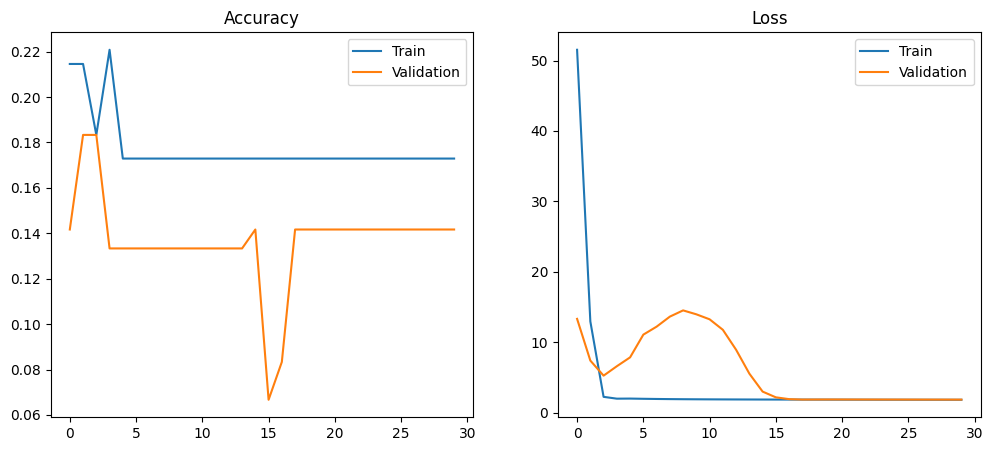

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(['Train','Validation'])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(['Train','Validation'])

plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step


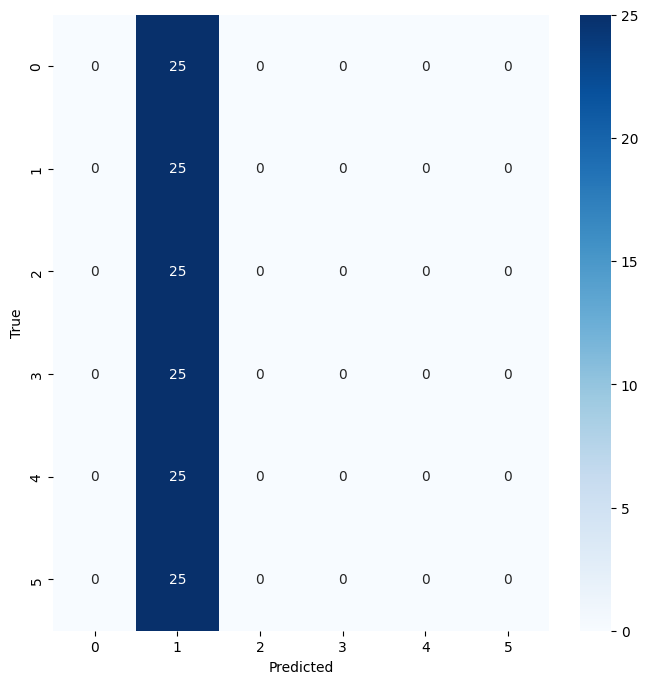

In [ ]:
pred = model.predict(X_test)

pred = pred.argmax(axis=1)

cm = confusion_matrix(
    y_test,
    pred
)

plt.figure(figsize=(8,8))

sns.heatmap(
    cm,
    annot=True,
    cmap='Blues',
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

In [42]:
model.save("location_classifier.keras")